In [1]:
# Fuente de datos: INEC - Instituto Nacional de Estadística y Censos
# https://www.ecuadorencifras.gob.ec/justicia-y-crimen/
# Hoja "10.robo_domicilio" del archivo Datos de Seguridad Ecuador.xlsx
import pandas as pd
df = pd.read_excel('Datos_de_Seguridad_Ecuador.xlsx', 
                    sheet_name='10.robo_domicilio', 
                    header=3)
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'Datos_de_Seguridad_Ecuador.xlsx'

In [2]:
import os

In [3]:
print(os.getcwd())

/home/jhanavi/ProyectoG3/Proyecto_FinalG3/robo_domicilio


In [4]:
print(os.listdir())

['Datos de Seguridad Ecuador.xlsx:Zone.Identifier', '.ipynb_checkpoints', 'RoboDomicilio.ipynb', 'Datos de Seguridad Ecuador.xlsx']


In [5]:
import pandas as pd
# Lectura del Excel
df = pd.read_excel('Datos de Seguridad Ecuador.xlsx', 
                    sheet_name='10.robo_domicilio', 
                    header=3)
df.head()

,Unnamed: 0,Provincia de ocurrencia,Código cantón_DPA,Cantón de ocurrencia,2014-01-01 00:00:00,2014-02-01 00:00:00,2014-03-01 00:00:00,2014-04-01 00:00:00,2014-05-01 00:00:00,2014-06-01 00:00:00,...,2025-05-01 00:00:00,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00
0,NaN,Azuay,101.0,Cuenca,88,62,55,61,49,56,...,14,6,14,20,10,10,8,9,10,9
1,NaN,Azuay,102.0,Giron,1,3,2,3,0,4,...,0,0,0,0,1,1,0,0,1,0
2,NaN,Azuay,103.0,Gualaceo,10,5,9,8,8,4,...,0,0,0,1,0,0,0,1,0,0
3,NaN,Azuay,104.0,Nabon,4,0,1,1,1,2,...,0,0,1,1,0,1,0,0,0,1
4,NaN,Azuay,105.0,Paute,3,2,0,3,4,2,...,0,1,1,1,0,0,1,0,0,0


In [6]:
# Limpieza de columnas
df = df.drop(columns=['Unnamed: 0'])
df = df.rename(columns={'Provincia de ocurrencia': 'provincia', 
                         'Cantón de ocurrencia': 'canton'})
df.head()

,provincia,Código cantón_DPA,canton,2014-01-01 00:00:00,2014-02-01 00:00:00,2014-03-01 00:00:00,2014-04-01 00:00:00,2014-05-01 00:00:00,2014-06-01 00:00:00,2014-07-01 00:00:00,...,2025-05-01 00:00:00,2025-06-01 00:00:00,2025-07-01 00:00:00,2025-08-01 00:00:00,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00
0,Azuay,101.0,Cuenca,88,62,55,61,49,56,69,...,14,6,14,20,10,10,8,9,10,9
1,Azuay,102.0,Giron,1,3,2,3,0,4,2,...,0,0,0,0,1,1,0,0,1,0
2,Azuay,103.0,Gualaceo,10,5,9,8,8,4,5,...,0,0,0,1,0,0,0,1,0,0
3,Azuay,104.0,Nabon,4,0,1,1,1,2,1,...,0,0,1,1,0,1,0,0,0,1
4,Azuay,105.0,Paute,3,2,0,3,4,2,2,...,0,1,1,1,0,0,1,0,0,0


In [7]:
# Transformación de formato ancho a largo 
df_largo = df.melt(
    id_vars=['provincia', 'Código cantón_DPA', 'canton'],
    var_name='fecha',
    value_name='denuncias'
)
df_largo.head(10)

,provincia,Código cantón_DPA,canton,fecha,denuncias
0,Azuay,101.0,Cuenca,2014-01-01 00:00:00,88
1,Azuay,102.0,Giron,2014-01-01 00:00:00,1
2,Azuay,103.0,Gualaceo,2014-01-01 00:00:00,10
3,Azuay,104.0,Nabon,2014-01-01 00:00:00,4
4,Azuay,105.0,Paute,2014-01-01 00:00:00,3
5,Azuay,106.0,Pucara,2014-01-01 00:00:00,0
6,Azuay,107.0,San Fernando,2014-01-01 00:00:00,0
7,Azuay,108.0,Santa Isabel,2014-01-01 00:00:00,1
8,Azuay,109.0,Sigsig,2014-01-01 00:00:00,0
9,Azuay,110.0,Oña,2014-01-01 00:00:00,0


In [8]:
print(df_largo.shape) 

(32412, 5)


In [9]:
print(df_largo['provincia'].unique())

<StringArray>
[                         'Azuay',                        'Bolívar',
                          'Cañar',                         'Carchi',
                       'Cotopaxi',                     'Chimborazo',
                         'El Oro',                     'Esmeraldas',
                         'Guayas',                       'Imbabura',
                           'Loja',                       'Los Ríos',
                         'Manabí',                'Morona Santiago',
                           'Napo',                        'Pastaza',
                      'Pichincha',                     'Tungurahua',
               'Zamora Chinchipe',                      'Galápagos',
                      'Sucumbíos',                       'Orellana',
 'Santo Domingo De Los Tsáchilas',                    'Santa Elena',
                 'Total Nacional']
Length: 25, dtype: str


In [10]:
df_largo['anio'] = df_largo['fecha'].dt.year

AttributeError: Can only use .dt accessor with datetimelike values

In [11]:
df_largo['fecha'] = pd.to_datetime(df_largo['fecha'])

In [12]:
df_largo['anio'] = df_largo['fecha'].dt.year

In [13]:
# Separación de datos parte nacional y provincias
df_nacional = df_largo[df_largo['provincia'] == 'Total Nacional']

In [14]:
# Separación de datos parte nacional y provincias
df_provincias = df_largo[df_largo['provincia'] != 'Total Nacional']

In [15]:
print(df_nacional.head())

           provincia  Código cantón_DPA          canton      fecha  denuncias  \
221   Total Nacional                NaN  Total Nacional 2014-01-01       1635   
443   Total Nacional                NaN  Total Nacional 2014-02-01       1315   
665   Total Nacional                NaN  Total Nacional 2014-03-01       1584   
887   Total Nacional                NaN  Total Nacional 2014-04-01       1469   
1109  Total Nacional                NaN  Total Nacional 2014-05-01       1375   

      anio  
221   2014  
443   2014  
665   2014  
887   2014  
1109  2014  


In [16]:
print(df_provincias['provincia'].nunique())

24


In [17]:
# Tabla que muestra el total de denuncias por provincia
tabla_provincias = df_provincias.groupby('provincia')['denuncias'].sum().sort_values(ascending=False)

In [18]:
tabla_provincias = tabla_provincias.reset_index()

In [19]:
tabla_provincias.columns = ['provincia', 'total_denuncias']

In [20]:
print(tabla_provincias)

                         provincia  total_denuncias
0                           Guayas            31134
1                        Pichincha            28483
2                           Manabí            10001
3                            Azuay             6631
4                           El Oro             6383
5                       Esmeraldas             6350
6                         Los Ríos             6211
7                      Santa Elena             4462
8   Santo Domingo De Los Tsáchilas             4198
9                       Chimborazo             3842
10                            Loja             3536
11                        Imbabura             3212
12                      Tungurahua             2949
13                        Cotopaxi             2465
14                       Sucumbíos             2386
15                        Orellana             2266
16                           Cañar             2140
17                 Morona Santiago             1784
18          

In [22]:
import matplotlib.pyplot as plt

In [23]:
# Gráfico que muestra la evolución nacional por año
nacional_por_anio = df_nacional.groupby('anio')['denuncias'].sum()

In [24]:
print(nacional_por_anio)

anio
2014    17707
2015    19347
2016    16190
2017    14575
2018    12428
2019    11099
2020     7369
2021     8198
2022     8386
2023     7226
2024     5699
2025     4407
2026      630
Name: denuncias, dtype: int64


In [25]:
fig = plt.figure(figsize=(9,5))

<Figure size 900x500 with 0 Axes>

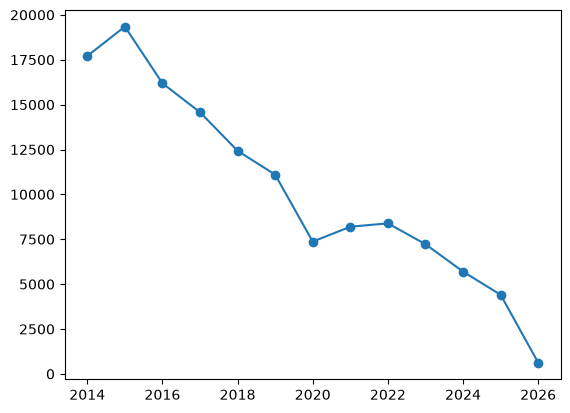

In [26]:
plt.plot(nacional_por_anio.index, nacional_por_anio.values, marker='o')

Text(0.5, 1.0, 'Robo a Domicilio en Ecuador - Total Nacional por Año')

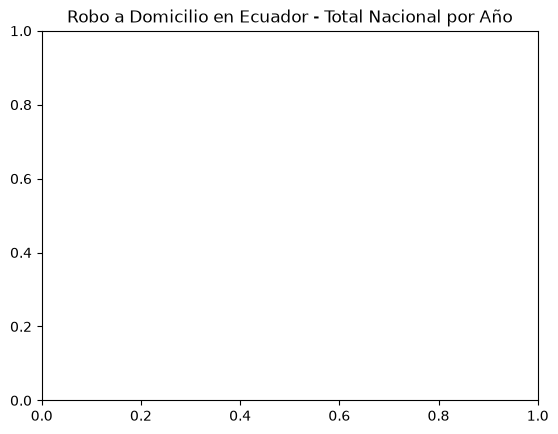

In [27]:
plt.title('Robo a Domicilio en Ecuador - Total Nacional por Año')

Text(0.5, 0, 'Año')

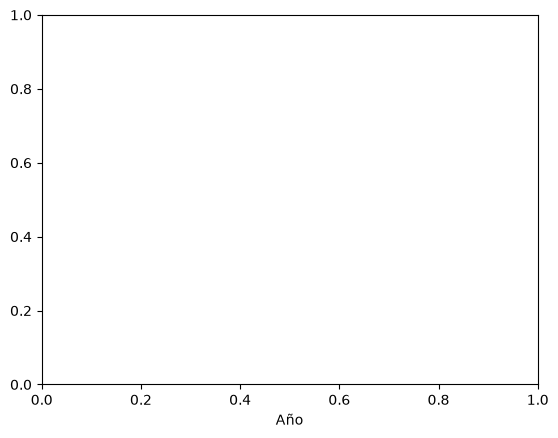

In [28]:
plt.xlabel('Año')

Text(0, 0.5, 'Número de denuncias')

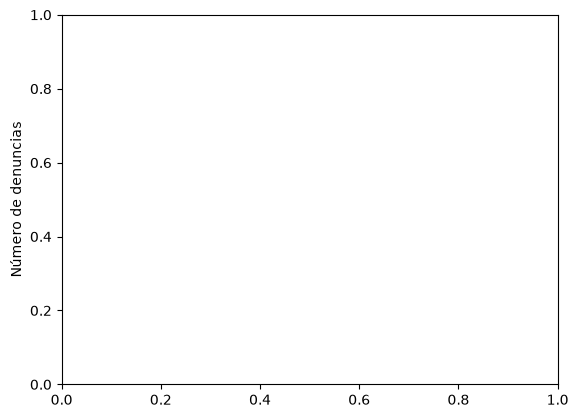

In [30]:
plt.ylabel('Número de denuncias')

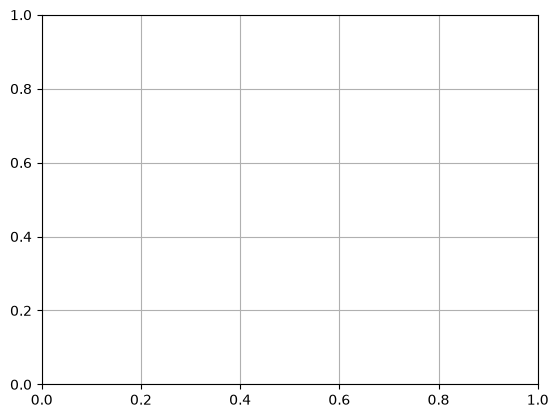

In [31]:
plt.grid()

In [32]:
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [33]:
plt.savefig('robo_domicilio_por_anio.png')

<Figure size 640x480 with 0 Axes>

In [34]:
plt.show()

anio
2014    17707
2015    19347
2016    16190
2017    14575
2018    12428
2019    11099
2020     7369
2021     8198
2022     8386
2023     7226
2024     5699
2025     4407
2026      630
Name: denuncias, dtype: int64


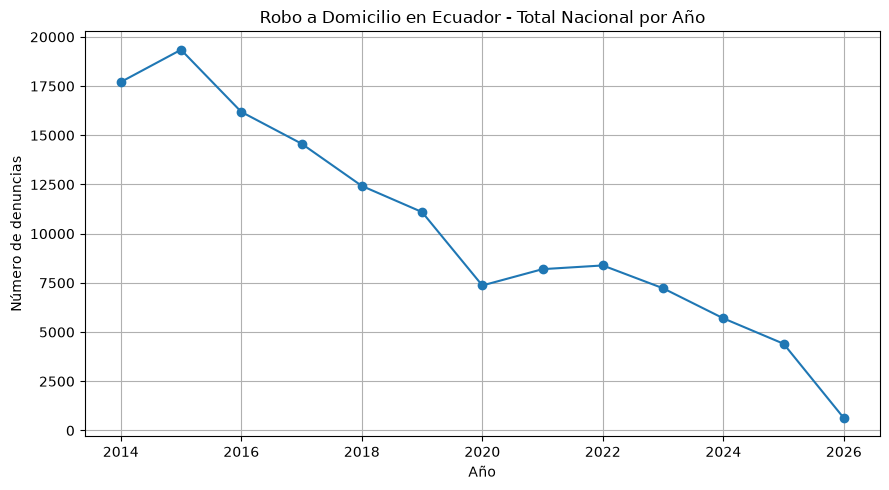

In [35]:
import matplotlib.pyplot as plt

nacional_por_anio = df_nacional.groupby('anio')['denuncias'].sum()
print(nacional_por_anio)

fig = plt.figure(figsize=(9,5))
plt.plot(nacional_por_anio.index, nacional_por_anio.values, marker='o')
plt.title('Robo a Domicilio en Ecuador - Total Nacional por Año')
plt.xlabel('Año')
plt.ylabel('Número de denuncias')
plt.grid()
plt.tight_layout()
plt.savefig('robo_domicilio_por_anio.png')
plt.show()

In [36]:
print(tabla_provincias)

                         provincia  total_denuncias
0                           Guayas            31134
1                        Pichincha            28483
2                           Manabí            10001
3                            Azuay             6631
4                           El Oro             6383
5                       Esmeraldas             6350
6                         Los Ríos             6211
7                      Santa Elena             4462
8   Santo Domingo De Los Tsáchilas             4198
9                       Chimborazo             3842
10                            Loja             3536
11                        Imbabura             3212
12                      Tungurahua             2949
13                        Cotopaxi             2465
14                       Sucumbíos             2386
15                        Orellana             2266
16                           Cañar             2140
17                 Morona Santiago             1784
18          

In [37]:
tabla_provincias.to_csv('tabla_provincias.csv', index=False)